<a href="https://colab.research.google.com/github/pondpatipatpankaew/GE337/blob/main/Lab/Lab_4_%E0%B8%9B%E0%B8%8F%E0%B8%B4%E0%B8%9E%E0%B8%B1%E0%B8%92%E0%B8%99%E0%B9%8C_6606520168.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Install + Import + Mount Drive

In [19]:
!pip install rasterio geopandas folium -q

# import library ที่ใช้ทั้งหมด
import rasterio
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# เชื่อม Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


โหลด Raster + Metadata

In [20]:
# โหลดภาพ Sentinel-2
src = rasterio.open('/content/drive/MyDrive/Labdata/Lab4/Lopburi2025.tif')

# แสดงข้อมูลพื้นฐานของภาพ
print("Number of bands:", src.count)
print("CRS:", src.crs)
print("Bounds:", src.bounds)

Number of bands: 12
CRS: EPSG:4326
Bounds: BoundingBox(left=100.13614675451322, bottom=14.347898649664831, right=101.78283045477642, top=16.021511016011036)


แยก Band + คำนวณ NDVI

In [21]:
# อ่าน band ที่สำคัญ
B2 = src.read(2)   # Blue
B3 = src.read(3)   # Green
B4 = src.read(4)   # Red
B8 = src.read(8)   # NIR
B11 = src.read(11) # SWIR
B12 = src.read(12) # SWIR

# คำนวณ NDVI (ใช้แยกพืชพรรณ)
NDVI = (B8 - B4) / (B8 + B4 + 1e-10)

โหลด Vector + รวม class

In [22]:
# โหลด shapefile
forest = gpd.read_file('/content/drive/MyDrive/Labdata/Lab4/forest.shp')
agri = gpd.read_file('/content/drive/MyDrive/Labdata/Lab4/agriculture.shp')
urban = gpd.read_file('/content/drive/MyDrive/Labdata/Lab4/urban.shp')
water = gpd.read_file('/content/drive/MyDrive/Labdata/Lab4/water.shp')

# กำหนด label ให้แต่ละ class
forest['class'] = 'forest'
agri['class'] = 'agriculture'
urban['class'] = 'urban'
water['class'] = 'water'

# รวมข้อมูลทั้งหมด
points = gpd.GeoDataFrame(
    pd.concat([forest, agri, urban, water], ignore_index=True)
)

แปลง CRS + ตรวจสอบตำแหน่ง

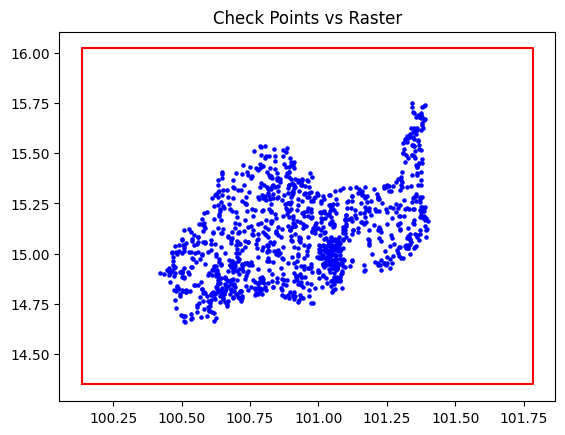

In [23]:
# แปลง CRS ของจุดให้ตรงกับ raster
points = points.to_crs(src.crs)

# สร้างพิกัด X,Y
points['x'] = points.geometry.x
points['y'] = points.geometry.y

# ตรวจสอบว่าจุดอยู่ใน raster หรือไม่
plt.scatter(points['x'], points['y'], s=5, c='blue')

bounds = src.bounds
plt.plot(
    [bounds.left, bounds.right, bounds.right, bounds.left, bounds.left],
    [bounds.bottom, bounds.bottom, bounds.top, bounds.top, bounds.bottom],
    color='red'
)

plt.title("Check Points vs Raster")
plt.show()

Extract Pixel → DataFrame

In [24]:
# แปลงพิกัดเป็น row/col ของ raster
rows, cols = rasterio.transform.rowcol(
    src.transform,
    points['x'],
    points['y']
)

# ดึงค่าจากแต่ละ band
df = pd.DataFrame({
    'B2': B2[rows, cols],
    'B3': B3[rows, cols],
    'B4': B4[rows, cols],
    'B8': B8[rows, cols],
    'B11': B11[rows, cols],
    'B12': B12[rows, cols],
    'NDVI': NDVI[rows, cols],
    'class': points['class'].values
})

Clean Data

In [25]:
# ลบค่า NaN / infinite
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

# ลบ pixel ที่เป็น nodata (ค่า 0)
df = df[(df[['B2','B3','B4','B8','B11','B12']].sum(axis=1) > 0)]

df.head()

,B2,B3,B4,B8,B11,B12,NDVI,class
0,4312,5027,6809,9719,14713,12766,0.176065,forest
1,3801,4745,6803,9968,15538,12648,0.188719,forest
2,5472,7399,10322,20722,23488,17039,0.335008,forest
3,3277,4535,6514,15630,16816,12674,0.411669,forest
4,3454,4319,5158,14097,14988,9214,0.464243,forest


เตรียม ML

In [26]:
from sklearn.model_selection import train_test_split

# Feature และ label
X = df[['B2','B3','B4','B8','B11','B12','NDVI']]
y = df['class']

# แบ่ง train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Random Forest + Grid Search

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# ตั้ง parameter
param_grid = {
    'n_estimators': [50,100,200],
    'max_depth': [5,10,None]
}

# หา model ที่ดีที่สุด
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best RF params:", grid.best_params_)

Best RF params: {'max_depth': None, 'n_estimators': 200}


Evaluate RF

In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = best_rf.predict(X_test)

print("RF Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

RF Accuracy: 0.5861111111111111
[[51  6 23 11]
 [14 64 14  2]
 [20 15 53  4]
 [16  9 15 43]]
              precision    recall  f1-score   support

 agriculture       0.50      0.56      0.53        91
      forest       0.68      0.68      0.68        94
       urban       0.50      0.58      0.54        92
       water       0.72      0.52      0.60        83

    accuracy                           0.59       360
   macro avg       0.60      0.58      0.59       360
weighted avg       0.60      0.59      0.59       360



Feature Importance

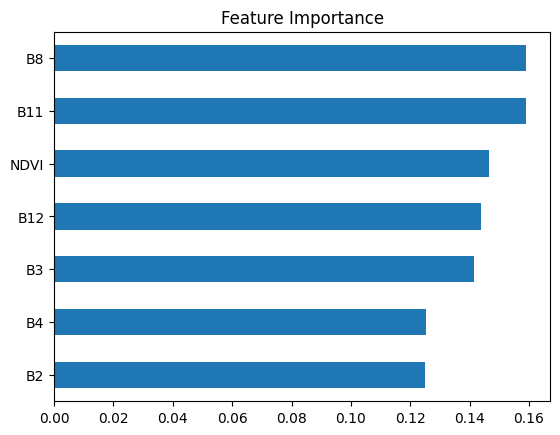

In [29]:
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

Random Forest Map

In [30]:
# เตรียมข้อมูลทั้งภาพ
rows_img, cols_img = B2.shape

X_all = pd.DataFrame({
    'B2': B2.flatten(),
    'B3': B3.flatten(),
    'B4': B4.flatten(),
    'B8': B8.flatten(),
    'B11': B11.flatten(),
    'B12': B12.flatten(),
    'NDVI': NDVI.flatten()
})

# clean
X_all = X_all.replace([np.inf, -np.inf], np.nan)
X_all = X_all.fillna(0)

# predict
y_all = best_rf.predict(X_all)

# reshape
classified_rf = y_all.reshape(rows_img, cols_img)

SVM Model

In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# grid search SVM
param_grid_svm = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid_svm = GridSearchCV(SVC(), param_grid_svm, cv=3)
grid_svm.fit(X_train_scaled, y_train)

best_svm = grid_svm.best_estimator_

print("Best SVM params:", grid_svm.best_params_)

Best SVM params: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


Evaluate SVM

In [32]:
y_pred_svm = best_svm.predict(X_test_scaled)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.625
[[56 12 19  4]
 [ 9 72 13  0]
 [19 15 55  3]
 [22 10  9 42]]
              precision    recall  f1-score   support

 agriculture       0.53      0.62      0.57        91
      forest       0.66      0.77      0.71        94
       urban       0.57      0.60      0.59        92
       water       0.86      0.51      0.64        83

    accuracy                           0.62       360
   macro avg       0.65      0.62      0.62       360
weighted avg       0.65      0.62      0.63       360



SVM Map

In [33]:
# scale ทั้งภาพ
X_all_scaled = scaler.transform(X_all)

# predict
y_all_svm = best_svm.predict(X_all_scaled)

# reshape
classified_svm = y_all_svm.reshape(rows_img, cols_img)

Visualization + Compare

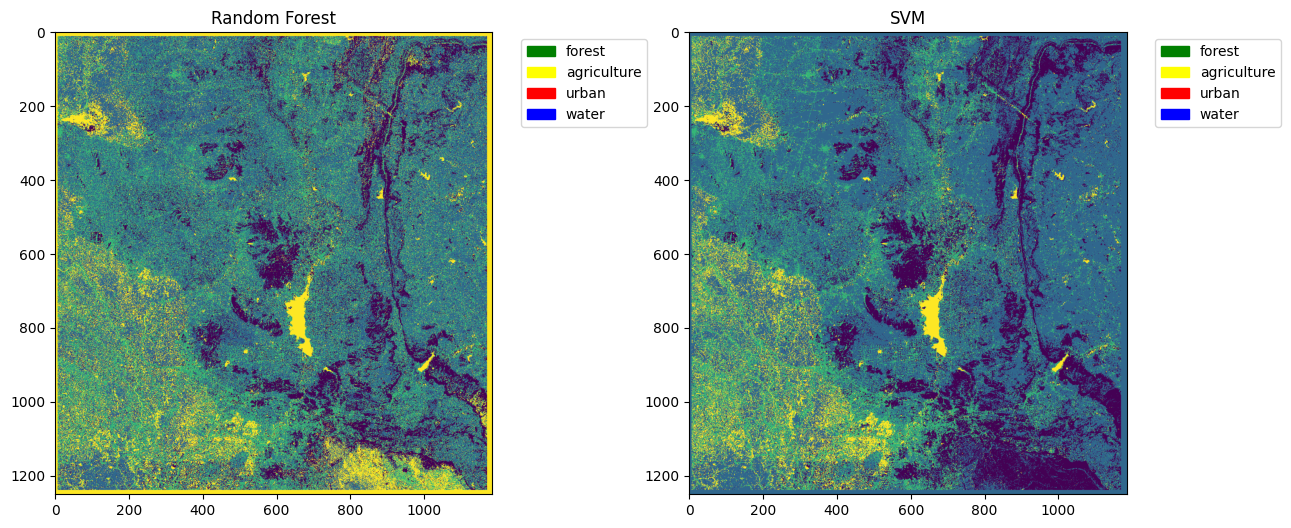

In [34]:
import matplotlib.patches as mpatches

# กำหนดสี + label
colors = ['green','yellow','red','blue']
labels = ['forest','agriculture','urban','water']

patches = [mpatches.Patch(color=colors[i], label=labels[i]) for i in range(4)]

plt.figure(figsize=(15,6))

# Random Forest
plt.subplot(1,2,1)
plt.imshow(rf_map)
plt.title("Random Forest")
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

# SVM
plt.subplot(1,2,2)
plt.imshow(svm_map)
plt.title("SVM")
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

วิเคราะห์ความแตกต่าง

Difference (%): 30.05318951589783


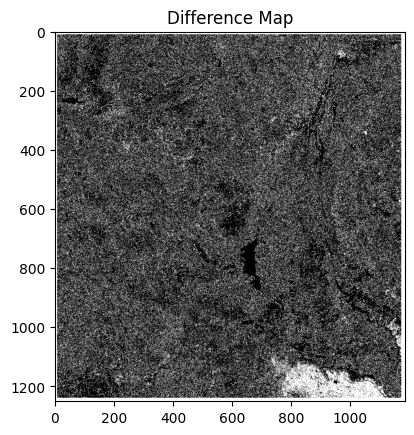

In [35]:
# เปอร์เซ็นต์ความต่าง
diff_pixels = np.sum(rf_map != svm_map)
total_pixels = rf_map.size

print("Difference (%):", (diff_pixels/total_pixels)*100)

# difference map
diff_map = (rf_map != svm_map)

plt.imshow(diff_map, cmap='gray')
plt.title("Difference Map")
plt.show()


===== Random Forest =====
Accuracy: 0.6042

Classification Report:
              precision    recall  f1-score   support

 agriculture       0.54      0.58      0.56        60
      forest       0.69      0.76      0.72        62
       urban       0.50      0.55      0.52        60
       water       0.73      0.52      0.61        58

    accuracy                           0.60       240
   macro avg       0.62      0.60      0.60       240
weighted avg       0.61      0.60      0.60       240

Confusion Matrix:
 [[35  5 16  4]
 [ 6 47  8  1]
 [12  9 33  6]
 [12  7  9 30]]


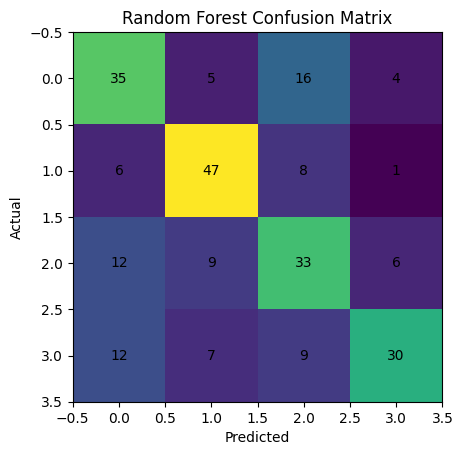


===== SVM =====
Accuracy: 0.6083

Classification Report:
              precision    recall  f1-score   support

 agriculture       0.53      0.55      0.54        60
      forest       0.62      0.79      0.70        62
       urban       0.55      0.60      0.57        60
       water       0.85      0.48      0.62        58

    accuracy                           0.61       240
   macro avg       0.64      0.61      0.61       240
weighted avg       0.63      0.61      0.61       240

Confusion Matrix:
 [[33 11 13  3]
 [ 4 49  9  0]
 [10 12 36  2]
 [15  7  8 28]]


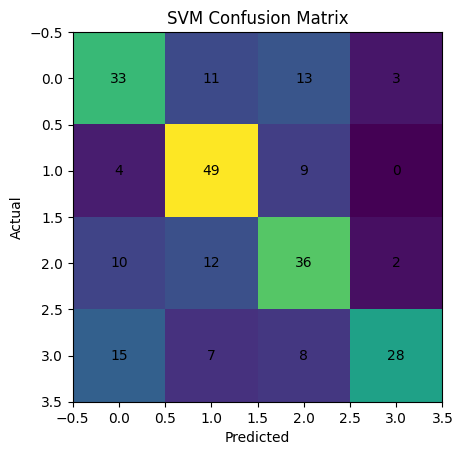


===== Comparison =====
RF Accuracy: 0.6042
SVM Accuracy: 0.6083


In [36]:
# ====== Import ======
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ====== Split ======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ====== Scaling (SVM) ======
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ====== Models ======
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
svm_model = SVC(kernel='rbf', C=1, gamma='scale')

# ====== Train ======
rf_model.fit(X_train, y_train)
svm_model.fit(X_train_scaled, y_train)

# ====== Predict ======
rf_pred = rf_model.predict(X_test)
svm_pred = svm_model.predict(X_test_scaled)

# ====== Evaluate Function ======
def evaluate(name, y_test, y_pred):
    print(f"\n===== {name} =====")

    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:\n", cm)

    # plot
    plt.figure()
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()

    return acc

# ====== Run ======
rf_acc = evaluate("Random Forest", y_test, rf_pred)
svm_acc = evaluate("SVM", y_test, svm_pred)

# ====== Compare ======
print("\n===== Comparison =====")
print(f"RF Accuracy: {rf_acc:.4f}")
print(f"SVM Accuracy: {svm_acc:.4f}")

## **คำถามท้าย Lab**
### **1. ทำไมการเลือก Features ที่เหมาะสมจึงสำคัญใน Machine Learning?**

การเลือก Features ที่เหมาะสมช่วยให้โมเดลเรียนรู้ได้แม่นยำขึ้น เพราะเป็นตัวแทนของข้อมูล หากเลือกไม่ดีหรือมี noise มาก จะทำให้โมเดลสับสนและประสิทธิภาพลดลง

### **2. เปรียบเทียบระหว่าง Random Forest และ SVM ในบริบทของปัญหานี้**

Random Forest เหมาะกับข้อมูลหลายตัวแปรและทนต่อ noise ได้ดี ไม่ต้อง scaling มาก
SVM ให้ความแม่นยำสูงในบางกรณี แต่ต้องปรับพารามิเตอร์และทำ scaling
โดยทั่วไป Random Forest เหมาะกับข้อมูลภาพดาวเทียมมากกว่า

จากผลพบว่า SVM ให้ค่า Accuracy สูงกว่าเล็กน้อย (0.6083) เมื่อเทียบกับ Random Forest (0.6042) อย่างไรก็ตาม Random Forest ให้ผลลัพธ์ที่มีความเสถียรมากกว่า ในขณะที่ SVM สามารถแยก class บางประเภทได้ละเอียดกว่า แต่มีความไวต่อ parameter มากกว่า
### **3. การใช้ NDVI เพียงอย่างเดียวเพียงพอสำหรับจำแนกประเภทพื้นที่หรือไม่? ทำไม?**

ไม่เพียงพอ เพราะ NDVI บอกได้แค่ความเขียว ไม่สามารถแยกประเภทพื้นที่ทั้งหมดได้ จึงควรใช้ร่วมกับ band อื่นหรือ index เช่น NDWI, NDBI

นอกจากนี้ NDVI ยังไม่สามารถแยกพื้นที่เมืองและแหล่งน้ำได้อย่างมีประสิทธิภาพ ดังนั้นจึงจำเป็นต้องใช้ข้อมูลจากหลาย Spectral Bands และดัชนีอื่นๆ เช่น NDWI หรือ NDBI ร่วมกัน เพื่อเพิ่มความแม่นยำของโมเดล

### **4. หากต้องการเพิ่มความแม่นยำของแบบจำลอง ควรทำอย่างไร?**

เพิ่มข้อมูลตัวอย่าง, เลือก features ให้เหมาะสม, ปรับพารามิเตอร์โมเดล, ทำ data balancing และลด noise ควรเพิ่ม features เช่น NDWI และ NDBI เพื่อช่วยแยกน้ำและพื้นที่เมือง รวมถึงเพิ่มจำนวน training data และปรับสมดุลของข้อมูล

### **5. ปัจจัยใดที่อาจทำให้แบบจำลองจำแนกประเภทของพื้นที่ผิดพลาด?**

ข้อมูลไม่เพียงพอ, มี noise, class คล้ายกัน, feature ไม่เหมาะสม, ความคลาดเคลื่อนพิกัด และความละเอียดภาพต่ำ ความสับสนระหว่าง class เกิดจากลักษณะ spectral ที่คล้ายกัน เช่น ป่าและเกษตร รวมถึงข้อจำกัดของการใช้ NDVI เพียงอย่างเดียว